# Connected Denotation and Contextual Representation: Experiment Suite

| Study | Mimamsa Concept | Computational Target | Model(s) | Data |
|-------|----------------|---------------------|----------|------|
| 1 | Akanksha (mutual expectancy) | Attention on dependency arcs + paired arc knockout | BERT | UD English EWT |
| 2 | Yogyata (semantic fitness) | Noise patching + semantic swap localization | GPT-2, LLaMA 3.1 8B | Minimal pairs (199) |
| 3 | Sannidhi (contiguity) | Attention decay + functional distance test | BERT, GPT-2, LLaMA 3.1 8B | Prose passages (313 + 50 long) |
| 4 | Polysemy crossover | Sense vs lexical identity separability | BERT| Balanced polysemy templates (50/word) |

In [ ]:
!pip install transformer-lens conllu -q

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.metrics import silhouette_score
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
import json, os, warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


In [2]:
from huggingface_hub import login
import getpass
hf_token = getpass.getpass("Enter Hugging Face token: ")
login(token=hf_token)

Enter Hugging Face token: ··········


In [ ]:
from google.colab import files
files.upload()


In [ ]:
from transformer_lens import HookedTransformer
from transformers import BertTokenizerFast, BertModel, BertForMaskedLM

bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained(
    'bert-base-uncased', output_attentions=True, output_hidden_states=True
).to(DEVICE).eval()
bert_mlm = BertForMaskedLM.from_pretrained('bert-base-uncased').to(DEVICE).eval()
print('BERT loaded (encoder + MLM)')

gpt2 = HookedTransformer.from_pretrained('gpt2', device=DEVICE)
print(f'GPT-2 loaded: {gpt2.cfg.n_layers}L, {gpt2.cfg.n_heads}H')

llama = HookedTransformer.from_pretrained_no_processing(
    'meta-llama/Llama-3.1-8B', device=DEVICE, dtype=torch.float16
)
print(f'LLaMA 3.1 8B loaded: {llama.cfg.n_layers}L, {llama.cfg.n_heads}H')

In [5]:
sample_tok = llama.to_tokens('test')
_, sample_cache = llama.run_with_cache(sample_tok)
block0_hooks = sorted([k for k in sample_cache.keys() if 'blocks.0.' in k])
del sample_cache

ATTN_HOOK, MLP_HOOK = None, None
for h in block0_hooks:
    short = h.replace('blocks.0.', '')
    if short in ('hook_attn_out', 'attn.hook_result', 'attn.hook_z'):
        ATTN_HOOK = short
    if short == 'hook_mlp_out':
        MLP_HOOK = short
if ATTN_HOOK is None:
    for h in block0_hooks:
        short = h.replace('blocks.0.', '')
        if 'attn' in short and ('out' in short or 'result' in short):
            ATTN_HOOK = short
            break
if MLP_HOOK is None:
    for h in block0_hooks:
        short = h.replace('blocks.0.', '')
        if 'mlp' in short and 'out' in short:
            MLP_HOOK = short
            break

RESID_HOOK = 'hook_resid_post'
COMPONENTS = [c for c in [RESID_HOOK, ATTN_HOOK, MLP_HOOK] if c is not None]
print(f'Hooks: ATTN={ATTN_HOOK}, MLP={MLP_HOOK}')
print(f'Components: {COMPONENTS}')

Hooks: ATTN=hook_attn_out, MLP=hook_mlp_out
Components: ['hook_resid_post', 'hook_attn_out', 'hook_mlp_out']


---
# Study 1: Akanksha -- Syntactic Expectancy in Attention

## Data
Universal Dependencies English Web Treebank (UD EWT), gold-standard dependency parses. Sentences filtered to 5--30 words (N=500).

## Arc Classification
Obligatory (akanksha-type): nsubj, obj, iobj, csubj, ccomp, xcomp, cop, aux, mark, expl, nsubj:pass. Optional: advmod, amod, nmod, obl, advcl, appos, nummod, acl, acl:relcl.

## Methodology
Word-to-token alignment via `BertTokenizerFast.word_ids()`. Attention measured separately dep-to-head and head-to-dep. Sentence-level aggregation with Benjamini-Hochberg FDR correction across 144 heads. Distance-binned analysis controls for arc length confound.

## Causal Test: Paired Arc Knockout
For each obligatory arc, a distance-matched optional arc from the same sentence is identified. Attention along each arc is blocked via a custom 4D attention mask passed to the BERT encoder. Log-probability damage for the dependent token is measured. Paired design controls for distance and sentence-level variation.

In [8]:
import conllu
UD_DIR = 'ud_english_ewt'
UD_FILE = f'{UD_DIR}/en_ewt-ud-train.conllu'
if not os.path.exists(UD_FILE):
    os.makedirs(UD_DIR, exist_ok=True)
    !wget -q https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu -O {UD_FILE}
with open(UD_FILE, 'r') as f:
    ud_data = conllu.parse(f.read())
print(f'Loaded {len(ud_data)} sentences')

Loaded 12544 sentences


In [9]:
OBLIGATORY_DEPS = {
    'nsubj', 'obj', 'iobj', 'csubj', 'ccomp', 'xcomp',
    'cop', 'aux', 'mark', 'expl', 'nsubj:pass'
}
OPTIONAL_DEPS = {
    'advmod', 'amod', 'nmod', 'obl', 'advcl', 'appos',
    'nummod', 'acl', 'acl:relcl'
}

def extract_dependency_pairs(sentence, tokenizer, max_len=64):
    words = [t['form'] for t in sentence if isinstance(t['id'], int)]
    text = ' '.join(words)
    encoding = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=max_len, is_split_into_words=False
    )
    wids = encoding.word_ids(batch_index=0)
    word_to_first_token = {}
    for tok_idx, wid in enumerate(wids):
        if wid is not None and wid not in word_to_first_token:
            word_to_first_token[wid] = tok_idx
    pairs = []
    n_aligned, n_total = 0, 0
    for token in sentence:
        if not isinstance(token['id'], int):
            continue
        dep_word_idx = token['id'] - 1
        head_word_idx = token['head'] - 1
        dep_rel = token['deprel']
        if head_word_idx < 0:
            continue
        is_oblig = dep_rel in OBLIGATORY_DEPS
        is_opt = dep_rel in OPTIONAL_DEPS
        if not (is_oblig or is_opt):
            continue
        n_total += 1
        if dep_word_idx in word_to_first_token and head_word_idx in word_to_first_token:
            dep_tok = word_to_first_token[dep_word_idx]
            head_tok = word_to_first_token[head_word_idx]
            dist = abs(dep_tok - head_tok)
            pairs.append((head_tok, dep_tok, dep_rel, is_oblig, dist))
            n_aligned += 1
    return encoding, pairs, n_aligned, n_total

In [10]:
N_SENTENCES = 500
usable_sentences = [
    s for s in ud_data
    if 5 <= len([t for t in s if isinstance(t['id'], int)]) <= 30
][:N_SENTENCES]
print(f'Processing {len(usable_sentences)} sentences')

sent_level_data = []
align_success, align_total = 0, 0

with torch.no_grad():
    for sent_idx, sent in enumerate(tqdm(usable_sentences, desc='Attention extraction')):
        encoding, pairs, n_a, n_t = extract_dependency_pairs(sent, bert_tokenizer)
        align_success += n_a
        align_total += n_t
        if not pairs:
            continue
        input_ids = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)
        seq_len = input_ids.shape[1]
        outputs = bert_model(input_ids, attention_mask=attention_mask)
        for layer_idx in range(12):
            attn = outputs.attentions[layer_idx][0]
            for head_idx in range(12):
                ha = attn[head_idx]
                ob_d2h, ob_h2d, op_d2h, op_h2d = [], [], [], []
                for ht, dt, dr, is_ob, d in pairs:
                    if ht >= seq_len or dt >= seq_len:
                        continue
                    d2h = ha[dt, ht].item()
                    h2d = ha[ht, dt].item()
                    if is_ob:
                        ob_d2h.append(d2h)
                        ob_h2d.append(h2d)
                    else:
                        op_d2h.append(d2h)
                        op_h2d.append(h2d)
                if ob_d2h and op_d2h:
                    sent_level_data.append({
                        'sent_idx': sent_idx, 'layer': layer_idx, 'head': head_idx,
                        'mean_oblig_d2h': np.mean(ob_d2h), 'mean_opt_d2h': np.mean(op_d2h),
                        'mean_oblig_h2d': np.mean(ob_h2d), 'mean_opt_h2d': np.mean(op_h2d),
                        'mean_oblig_avg': (np.mean(ob_d2h) + np.mean(ob_h2d)) / 2,
                        'mean_opt_avg': (np.mean(op_d2h) + np.mean(op_h2d)) / 2,
                    })

df_sent = pd.DataFrame(sent_level_data)
print(f'Alignment: {align_success}/{align_total} ({100*align_success/max(align_total,1):.1f}%)')
print(f'Sentence-level rows: {len(df_sent)}')

Processing 500 sentences


Attention extraction:   0%|          | 0/500 [00:00<?, ?it/s]

Alignment: 4362/4362 (100.0%)
Sentence-level rows: 66960


In [11]:
results_s1 = []
for layer in range(12):
    for head in range(12):
        sub = df_sent[(df_sent['layer'] == layer) & (df_sent['head'] == head)]
        if len(sub) < 20:
            continue
        for direction, ocol, pcol in [
            ('d2h', 'mean_oblig_d2h', 'mean_opt_d2h'),
            ('h2d', 'mean_oblig_h2d', 'mean_opt_h2d'),
            ('avg', 'mean_oblig_avg', 'mean_opt_avg'),
        ]:
            diffs = sub[ocol].values - sub[pcol].values
            t_stat, p_val = stats.ttest_1samp(diffs, 0)
            d = np.mean(diffs) / max(np.std(diffs, ddof=1), 1e-12)
            results_s1.append({
                'layer': layer, 'head': head, 'direction': direction,
                'mean_diff': np.mean(diffs), 'cohens_d': d,
                't_stat': t_stat, 'p_value': p_val, 'n_sents': len(sub)
            })

df_s1 = pd.DataFrame(results_s1)
for direction in ['d2h', 'h2d', 'avg']:
    mask = df_s1['direction'] == direction
    _, pvals_corr, _, _ = multipletests(df_s1.loc[mask, 'p_value'], alpha=0.05, method='fdr_bh')
    df_s1.loc[mask, 'p_fdr'] = pvals_corr
    df_s1.loc[mask, 'sig_fdr'] = pvals_corr < 0.05

df_avg = df_s1[df_s1['direction'] == 'avg'].copy()
print(f"Significant heads (avg, FDR<0.05): {df_avg['sig_fdr'].sum()}/144")
print(df_avg.nlargest(10, 'cohens_d')[['layer','head','cohens_d','p_fdr','n_sents']].to_string(index=False))

Significant heads (avg, FDR<0.05): 94/144
 layer  head  cohens_d        p_fdr  n_sents
     4    10  0.804626 3.497896e-50      465
     7     1  0.749072 4.915115e-45      465
     6     9  0.663824 4.483769e-37      465
     7     8  0.609065 3.608225e-32      465
     6    10  0.583773 5.240101e-30      465
     5     7  0.566333 1.482502e-28      465
     7     9  0.494612 1.373922e-22      465
     8     4  0.491000 2.352636e-22      465
     8    10  0.489071 2.989909e-22      465
     8     5  0.470793 7.624931e-21      465


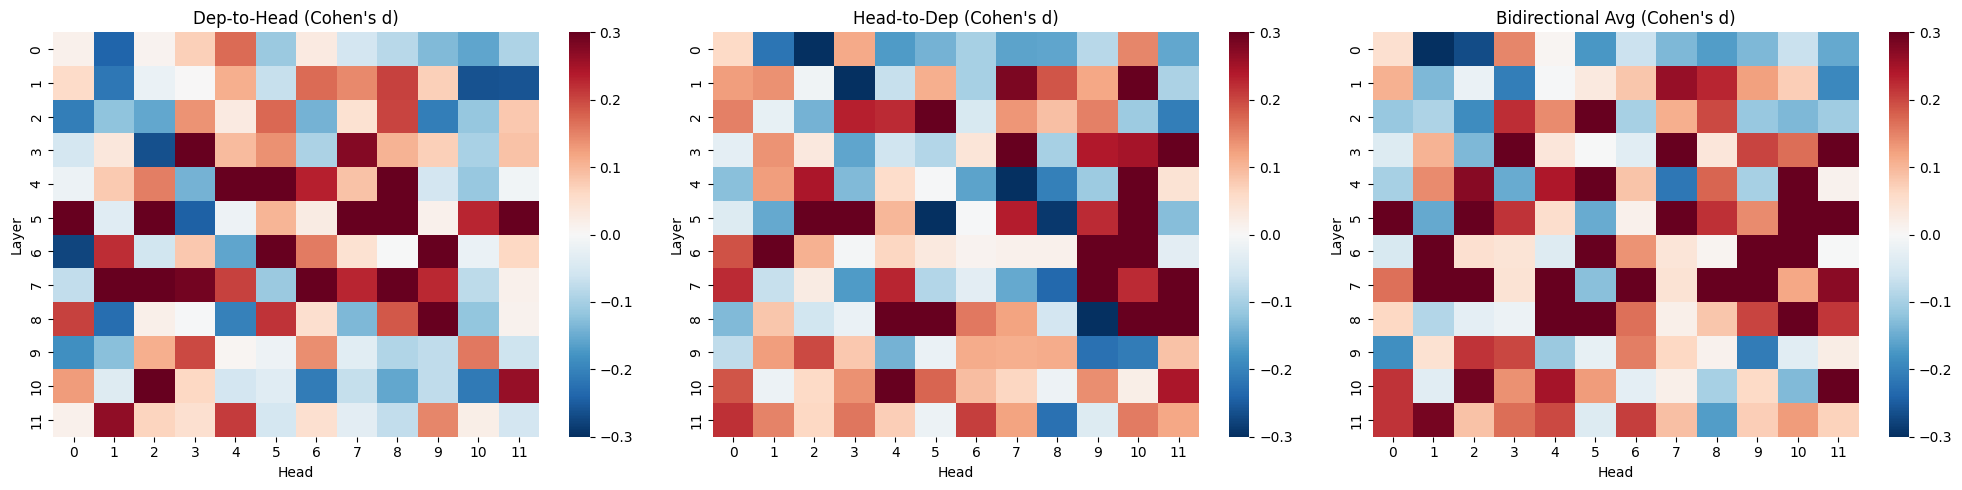

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax_idx, (direction, title_tag) in enumerate([
    ('d2h', 'Dep-to-Head'), ('h2d', 'Head-to-Dep'), ('avg', 'Bidirectional Avg')
]):
    sub = df_s1[df_s1['direction'] == direction]
    mat = np.zeros((12, 12))
    for _, row in sub.iterrows():
        mat[int(row['layer']), int(row['head'])] = row['cohens_d']
    sns.heatmap(mat, ax=axes[ax_idx], cmap='RdBu_r', center=0,
                vmin=-0.3, vmax=0.3, xticklabels=range(12), yticklabels=range(12))
    axes[ax_idx].set_xlabel('Head')
    axes[ax_idx].set_ylabel('Layer')
    axes[ax_idx].set_title(f"{title_tag} (Cohen's d)")
plt.tight_layout()
plt.savefig('study1_akanksha_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

s1_effect_matrix = np.zeros((12, 12))
for _, row in df_avg.iterrows():
    s1_effect_matrix[int(row['layer']), int(row['head'])] = row['cohens_d']

Distance-binned:   0%|          | 0/500 [00:00<?, ?it/s]

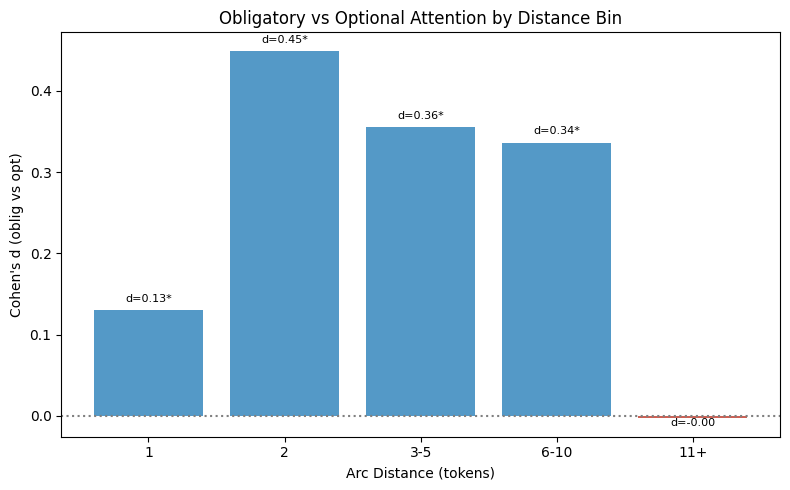

In [13]:
arc_level = []
with torch.no_grad():
    for sent_idx, sent in enumerate(tqdm(usable_sentences, desc='Distance-binned')):
        encoding, pairs, _, _ = extract_dependency_pairs(sent, bert_tokenizer)
        if not pairs:
            continue
        input_ids = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)
        seq_len = input_ids.shape[1]
        outputs = bert_model(input_ids, attention_mask=attention_mask)
        for ht, dt, dr, is_ob, dist in pairs:
            if ht >= seq_len or dt >= seq_len:
                continue
            attn_avg = np.mean([outputs.attentions[l][0].mean(dim=0)[dt, ht].item() for l in range(12)])
            arc_level.append({'is_oblig': is_ob, 'dist': dist, 'attn': attn_avg})

df_arc = pd.DataFrame(arc_level)
bins = [(1,1),(2,2),(3,5),(6,10),(11,999)]
bin_labels = ['1','2','3-5','6-10','11+']

fig, ax = plt.subplots(figsize=(8, 5))
for i, ((lo, hi), label) in enumerate(zip(bins, bin_labels)):
    sub = df_arc[(df_arc['dist'] >= lo) & (df_arc['dist'] <= hi)]
    ob = sub[sub['is_oblig']]['attn']
    op = sub[~sub['is_oblig']]['attn']
    if len(ob) < 5 or len(op) < 5:
        continue
    d = (ob.mean() - op.mean()) / np.sqrt((ob.var() + op.var()) / 2)
    _, p = stats.mannwhitneyu(ob, op, alternative='two-sided')
    ax.bar(i, d, color='#2980b9' if d > 0 else '#c0392b', alpha=0.8)
    sig = '*' if p < 0.05 else ''
    ax.text(i, d + 0.01 * np.sign(d), f'd={d:.2f}{sig}', ha='center', fontsize=8)
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels)
ax.set_xlabel('Arc Distance (tokens)')
ax.set_ylabel("Cohen's d (oblig vs opt)")
ax.set_title('Obligatory vs Optional Attention by Distance Bin')
ax.axhline(0, color='gray', ls=':')
plt.tight_layout()
plt.savefig('study1_distance_bins.png', dpi=150, bbox_inches='tight')
plt.show()

## Study 1b: Paired Arc Knockout (Causal Test)

In [14]:
def run_paired_arc_knockout(sentences, n_sents=200):
    paired_results = []
    with torch.no_grad():
        for sent in tqdm(sentences[:n_sents], desc='Paired arc knockout'):
            encoding, pairs, _, _ = extract_dependency_pairs(sent, bert_tokenizer)
            if len(pairs) < 2:
                continue
            oblig_arcs = [(h,d,r,dist) for h,d,r,is_ob,dist in pairs if is_ob]
            opt_arcs = [(h,d,r,dist) for h,d,r,is_ob,dist in pairs if not is_ob]
            if not oblig_arcs or not opt_arcs:
                continue
            input_ids = encoding['input_ids'].to(DEVICE)
            attn_mask = encoding['attention_mask'].to(DEVICE)
            seq_len = input_ids.shape[1]

            def get_damage(head_tok, dep_tok):
                if dep_tok >= seq_len or dep_tok == 0 or head_tok >= seq_len or dep_tok == head_tok:
                    return None
                masked_ids = input_ids.clone()
                original_id = masked_ids[0, dep_tok].item()
                masked_ids[0, dep_tok] = bert_tokenizer.mask_token_id
                clean_out = bert_mlm(masked_ids, attention_mask=attn_mask)
                clean_lp = F.log_softmax(clean_out.logits[0, dep_tok], dim=-1)[original_id].item()
                embeddings = bert_mlm.bert.embeddings(masked_ids)
                ext_mask = attn_mask[:, None, None, :].expand(-1, 1, seq_len, seq_len).clone().float()
                ext_mask[0, 0, dep_tok, head_tok] = 0.0
                ext_mask[0, 0, head_tok, dep_tok] = 0.0
                additive_mask = (1.0 - ext_mask) * torch.finfo(embeddings.dtype).min
                encoder_out = bert_mlm.bert.encoder(embeddings, attention_mask=additive_mask)
                ko_logits = bert_mlm.cls(encoder_out.last_hidden_state)
                ko_lp = F.log_softmax(ko_logits[0, dep_tok], dim=-1)[original_id].item()
                return clean_lp - ko_lp

            opt_by_dist = defaultdict(list)
            for h,d,r,dist in opt_arcs:
                opt_by_dist[dist].append((h,d,r))
            for h_ob,d_ob,r_ob,dist_ob in oblig_arcs:
                if dist_ob not in opt_by_dist or not opt_by_dist[dist_ob]:
                    continue
                h_op, d_op, r_op = opt_by_dist[dist_ob][0]
                dmg_ob = get_damage(h_ob, d_ob)
                dmg_op = get_damage(h_op, d_op)
                if dmg_ob is not None and dmg_op is not None:
                    paired_results.append({
                        'dist': dist_ob, 'oblig_damage': dmg_ob, 'opt_damage': dmg_op,
                        'diff': dmg_ob - dmg_op, 'oblig_rel': r_ob, 'opt_rel': r_op,
                    })
    return pd.DataFrame(paired_results)

df_paired = run_paired_arc_knockout(usable_sentences)
print(f'Paired comparisons: {len(df_paired)}')
print(f'Obligatory damage: {df_paired["oblig_damage"].mean():.4f}')
print(f'Optional damage: {df_paired["opt_damage"].mean():.4f}')
print(f'Mean diff (oblig - opt): {df_paired["diff"].mean():.4f}')
t, p = stats.ttest_1samp(df_paired['diff'], 0)
d = df_paired['diff'].mean() / df_paired['diff'].std()
print(f"Paired t-test: t={t:.3f}, p={p:.2e}, Cohen's d={d:.3f}")
t_w, p_w = stats.wilcoxon(df_paired['diff'])
print(f'Wilcoxon: W={t_w:.0f}, p={p_w:.2e}')

Paired arc knockout:   0%|          | 0/200 [00:00<?, ?it/s]

Paired comparisons: 484
Obligatory damage: 1.9011
Optional damage: 2.7353
Mean diff (oblig - opt): -0.8342
Paired t-test: t=-4.283, p=2.23e-05, Cohen's d=-0.195
Wilcoxon: W=47357, p=2.34e-04


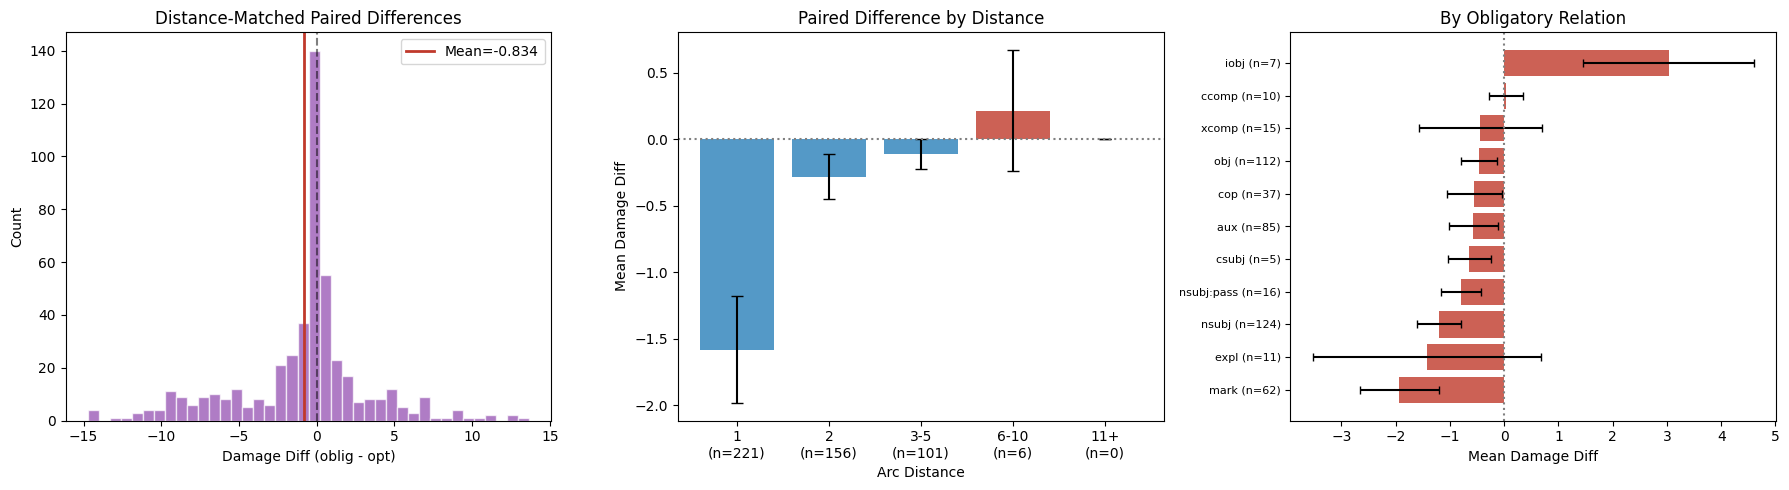

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_paired['diff'], bins=40, color='#8e44ad', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='black', ls='--', alpha=0.5)
axes[0].axvline(df_paired['diff'].mean(), color='#c0392b', ls='-', linewidth=2,
                label=f"Mean={df_paired['diff'].mean():.3f}")
axes[0].set_xlabel('Damage Diff (oblig - opt)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distance-Matched Paired Differences')
axes[0].legend()

bins_def = [(1,1),(2,2),(3,5),(6,10),(11,999)]
bin_labels = ['1','2','3-5','6-10','11+']
bm, bs, bn = [], [], []
for lo, hi in bins_def:
    sub = df_paired[(df_paired['dist'] >= lo) & (df_paired['dist'] <= hi)]['diff']
    bm.append(sub.mean() if len(sub) > 0 else 0)
    bs.append(sub.sem() if len(sub) > 1 else 0)
    bn.append(len(sub))
colors = ['#c0392b' if m > 0 else '#2980b9' for m in bm]
axes[1].bar(range(len(bin_labels)), bm, yerr=bs, color=colors, alpha=0.8, capsize=4)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels([f'{l}\n(n={n})' for l, n in zip(bin_labels, bn)])
axes[1].set_xlabel('Arc Distance')
axes[1].set_ylabel('Mean Damage Diff')
axes[1].set_title('Paired Difference by Distance')
axes[1].axhline(0, color='gray', ls=':')

by_rel = df_paired.groupby('oblig_rel')['diff'].agg(['mean','sem','count']).sort_values('mean')
axes[2].barh(range(len(by_rel)), by_rel['mean'], xerr=by_rel['sem'],
             color='#c0392b', alpha=0.8, capsize=3)
axes[2].set_yticks(range(len(by_rel)))
axes[2].set_yticklabels([f"{r} (n={int(c)})" for r, c in zip(by_rel.index, by_rel['count'])], fontsize=8)
axes[2].set_xlabel('Mean Damage Diff')
axes[2].set_title('By Obligatory Relation')
axes[2].axvline(0, color='gray', ls=':')
plt.tight_layout()
plt.savefig('study1_paired_knockout.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Study 2: Yogyata -- Semantic Fitness Localization

## Data
199 minimal pairs from `yogyata_minpairs_llama3_final.jsonl`. Each pair shares a `prompt_prefix` and diverges into plausible vs. implausible completion.

## Methodology
### 2a. Baseline behavioral discrimination
NLD and log-probability difference at the divergence position on LLaMA 3.1 8B.

### 2b. Noise-corruption activation patching (LLaMA)
Gaussian noise (sigma = 3x embedding std) corrupts the full embedding. Clean activations restored one component at a time per layer.

### 2c. Semantic swap activation patching (LLaMA + GPT-2)
Clean run = good sentence, corrupt run = bad sentence. For each layer, the attention or MLP output is patched from clean into corrupt at the LAST token position only (decision point). This avoids trivial token-replacement at the divergence position and isolates each layer's contribution to semantic preference recovery. Both LLaMA and GPT-2 tested for generality.

In [16]:
yogyata_pairs = []
with open('yogyata_minpairs_llama3_final.jsonl', 'r') as f:
    for line in f:
        yogyata_pairs.append(json.loads(line))
print(f'Loaded {len(yogyata_pairs)} minimal pairs')
type_counts = defaultdict(int)
for p in yogyata_pairs:
    type_counts[p['violation_type']] += 1
print('Types:', dict(type_counts))

Loaded 200 minimal pairs
Types: {'patient': 40, 'agent': 40, 'instrument': 40, 'location': 40, 'temporal': 40}


In [17]:
baseline_results = []
with torch.no_grad():
    for pair in tqdm(yogyata_pairs, desc='Baseline NLD'):
        tokens = llama.to_tokens(pair['prompt_prefix'])
        logits = llama(tokens)[0, -1]
        good_tok = llama.to_tokens(' ' + pair['good_continuation'])[0, 1]
        bad_tok = llama.to_tokens(' ' + pair['bad_continuation'])[0, 1]
        nld = (logits[good_tok] - logits[bad_tok]).item()
        lps = F.log_softmax(logits.float(), dim=-1)
        lpd = (lps[good_tok] - lps[bad_tok]).item()
        baseline_results.append({
            'pair_id': pair['pair_id'], 'violation_type': pair['violation_type'],
            'nld': nld, 'log_prob_diff': lpd
        })

df_baseline = pd.DataFrame(baseline_results)
t_stat, t_pval = stats.ttest_1samp(df_baseline['nld'], 0)
d = df_baseline['nld'].mean() / df_baseline['nld'].std()
print(f"NLD: mean={df_baseline['nld'].mean():.3f}, Cohen's d={d:.3f}, p={t_pval:.2e}")
print(f"Correct: {(df_baseline['nld'] > 0).sum()}/{len(df_baseline)} ({(df_baseline['nld'] > 0).mean()*100:.1f}%)")
for vt, grp in df_baseline.groupby('violation_type'):
    print(f'  {vt}: NLD={grp["nld"].mean():.3f}, correct={(grp["nld"]>0).sum()}/{len(grp)}')

Baseline NLD:   0%|          | 0/200 [00:00<?, ?it/s]

NLD: mean=9.346, Cohen's d=2.674, p=8.42e-93
Correct: 199/200 (99.5%)
  agent: NLD=8.261, correct=40/40
  instrument: NLD=6.563, correct=39/40
  location: NLD=10.639, correct=40/40
  patient: NLD=9.993, correct=40/40
  temporal: NLD=11.277, correct=40/40


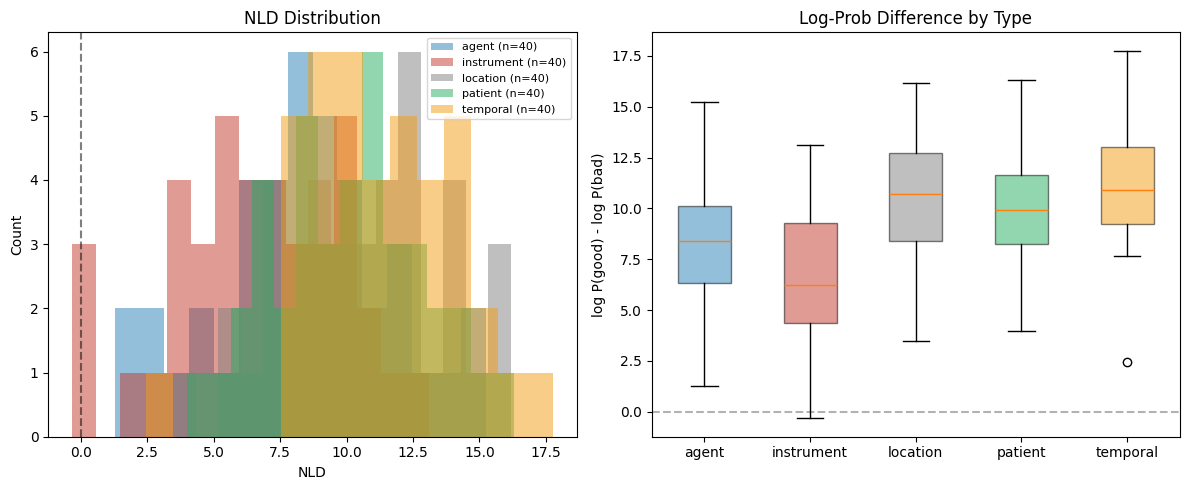

In [18]:
vtype_colors = {'instrument': '#c0392b', 'agent': '#2980b9', 'patient': '#27ae60', 'temporal': '#f39c12'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for vt in sorted(df_baseline['violation_type'].unique()):
    sub = df_baseline[df_baseline['violation_type'] == vt]
    axes[0].hist(sub['nld'], bins=15, alpha=0.5, label=f'{vt} (n={len(sub)})',
                 color=vtype_colors.get(vt, 'gray'))
axes[0].axvline(0, color='black', ls='--', alpha=0.5)
axes[0].set_xlabel('NLD')
axes[0].set_ylabel('Count')
axes[0].set_title('NLD Distribution')
axes[0].legend(fontsize=8)
bp_data = [df_baseline[df_baseline['violation_type']==vt]['log_prob_diff']
           for vt in sorted(df_baseline['violation_type'].unique())]
bp = axes[1].boxplot(bp_data, labels=sorted(df_baseline['violation_type'].unique()), patch_artist=True)
for patch, vt in zip(bp['boxes'], sorted(df_baseline['violation_type'].unique())):
    patch.set_facecolor(vtype_colors.get(vt, 'gray'))
    patch.set_alpha(0.5)
axes[1].set_ylabel('log P(good) - log P(bad)')
axes[1].set_title('Log-Prob Difference by Type')
axes[1].axhline(0, color='black', ls='--', alpha=0.3)
plt.tight_layout()
plt.savefig('study2_yogyata_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
N_LAYERS = llama.cfg.n_layers
sample_embed = llama.embed(llama.to_tokens('The quick brown fox jumps over the lazy dog'))
NOISE_STD = 3.0 * sample_embed.std().item()
print(f'Noise std: {NOISE_STD:.4f}')
torch.manual_seed(SEED)
noise_seeds = torch.randint(0, 2**31, (len(yogyata_pairs),))

def run_noise_patching(model, prefix_str, good_tok, bad_tok, noise_std, pair_seed):
    tokens = model.to_tokens(prefix_str)
    seq_len = tokens.shape[1]
    last_pos = seq_len - 1
    patch_positions = [last_pos]
    if last_pos > 0:
        patch_positions.append(last_pos - 1)
    clean_logits, clean_cache = model.run_with_cache(tokens)
    clean_diff = (clean_logits[0, -1, good_tok] - clean_logits[0, -1, bad_tok]).item()
    gen = torch.Generator(device=tokens.device)
    gen.manual_seed(pair_seed)
    def noise_hook(embed, hook):
        return embed + torch.randn(embed.shape, generator=gen, device=embed.device, dtype=embed.dtype) * noise_std
    gen.manual_seed(pair_seed)
    corrupt_logits = model.run_with_hooks(tokens, fwd_hooks=[('hook_embed', noise_hook)])
    corrupt_diff = (corrupt_logits[0, -1, good_tok] - corrupt_logits[0, -1, bad_tok]).item()
    denom = clean_diff - corrupt_diff
    if abs(denom) < 0.5:
        return None
    results = {'clean_diff': clean_diff, 'corrupt_diff': corrupt_diff, 'denom': denom}
    for layer in range(model.cfg.n_layers):
        for component in COMPONENTS:
            hook_name = f'blocks.{layer}.{component}'
            if hook_name not in clean_cache:
                continue
            clean_act = clean_cache[hook_name].clone()
            def restore(act, hook, ca=clean_act, pp=patch_positions):
                for pos in pp:
                    if pos < act.shape[1]:
                        act[:, pos, :] = ca[:, pos, :]
                return act
            gen.manual_seed(pair_seed)
            patched_logits = model.run_with_hooks(
                tokens, fwd_hooks=[('hook_embed', noise_hook), (hook_name, restore)]
            )
            patched_diff = (patched_logits[0, -1, good_tok] - patched_logits[0, -1, bad_tok]).item()
            results[f'{component}_L{layer}'] = (patched_diff - corrupt_diff) / denom
    return results

patch_results_all = []
with torch.no_grad():
    for idx, pair in enumerate(tqdm(yogyata_pairs, desc='Noise patching')):
        good_tok = llama.to_tokens(' ' + pair['good_continuation'])[0, 1]
        bad_tok = llama.to_tokens(' ' + pair['bad_continuation'])[0, 1]
        res = run_noise_patching(
            llama, pair['prompt_prefix'], good_tok.item(), bad_tok.item(),
            NOISE_STD, noise_seeds[idx].item()
        )
        if res is not None:
            res['violation_type'] = pair['violation_type']
            patch_results_all.append(res)
print(f'Noise patching: {len(patch_results_all)}/{len(yogyata_pairs)} pairs')

Noise std: 0.0276


Noise patching:   0%|          | 0/200 [00:00<?, ?it/s]

Noise patching: 199/200 pairs


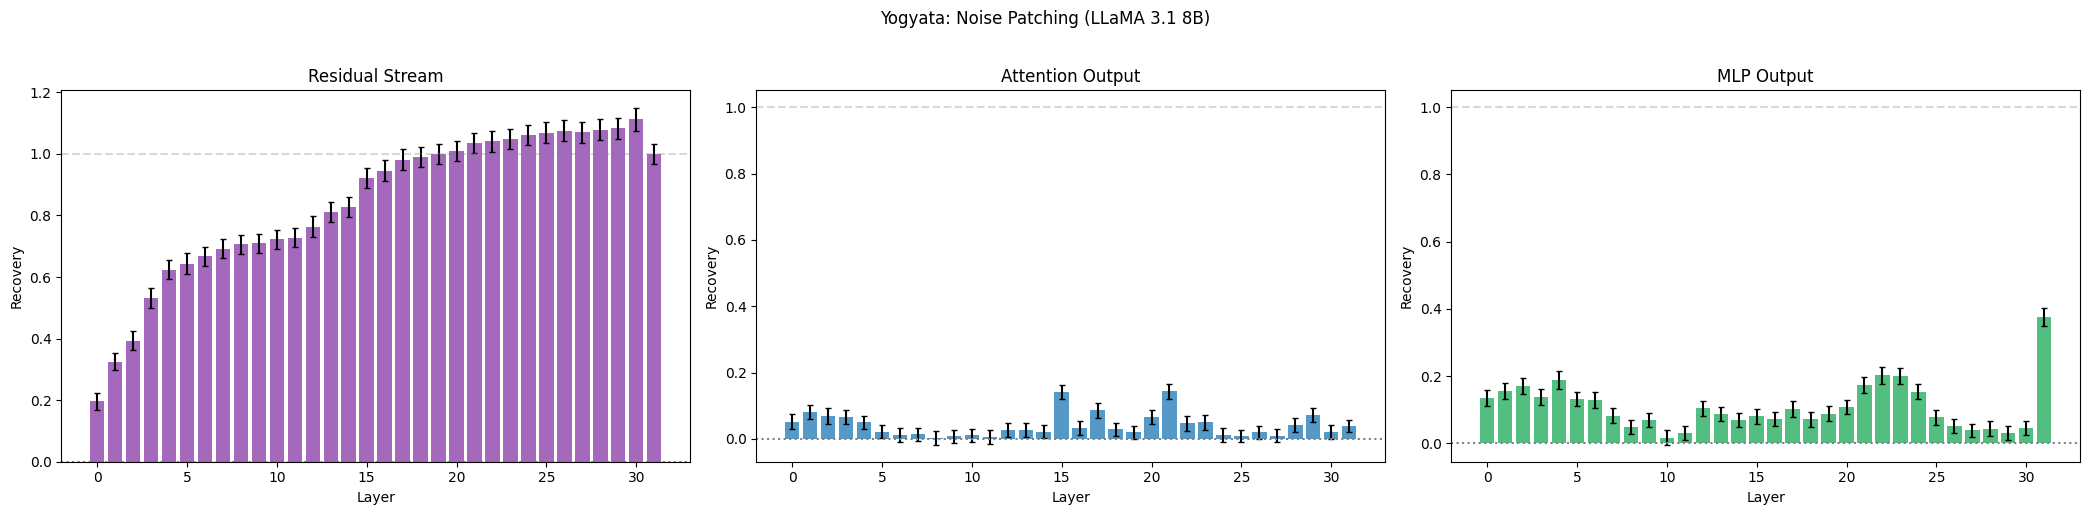

Residual Stream: peak layer 30 (recovery=1.112)
Attention Output: peak layer 21 (recovery=0.143)
MLP Output: peak layer 31 (recovery=0.376)


In [20]:
mean_clean = np.mean([r['clean_diff'] for r in patch_results_all])
mean_corrupt = np.mean([r['corrupt_diff'] for r in patch_results_all])
global_denom = mean_clean - mean_corrupt

ds_recovery = {}
for comp in COMPONENTS:
    rec = np.zeros(N_LAYERS)
    ci = np.zeros(N_LAYERS)
    for layer in range(N_LAYERS):
        key = f'{comp}_L{layer}'
        pds = [r['corrupt_diff'] + r[key] * r['denom'] for r in patch_results_all if key in r]
        if pds:
            rec[layer] = (np.mean(pds) - mean_corrupt) / global_denom
            boots = [np.mean(np.random.choice(pds, len(pds), replace=True)) for _ in range(500)]
            ci[layer] = np.std([(b - mean_corrupt) / global_denom for b in boots])
    ds_recovery[comp] = (rec, ci)

comp_colors = {RESID_HOOK: '#8e44ad', ATTN_HOOK: '#2980b9', MLP_HOOK: '#27ae60'}
comp_labels = {RESID_HOOK: 'Residual Stream', ATTN_HOOK: 'Attention Output', MLP_HOOK: 'MLP Output'}

fig, axes = plt.subplots(1, len(COMPONENTS), figsize=(7*len(COMPONENTS), 5))
if len(COMPONENTS) == 1: axes = [axes]
for ax, comp in zip(axes, COMPONENTS):
    r, c = ds_recovery[comp]
    ax.bar(range(N_LAYERS), r, yerr=c, color=comp_colors.get(comp,'gray'), alpha=0.8, capsize=2)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Recovery')
    ax.set_title(comp_labels.get(comp, comp))
    ax.axhline(0, color='gray', ls=':')
    ax.axhline(1, color='gray', ls='--', alpha=0.3)
plt.suptitle('Yogyata: Noise Patching (LLaMA 3.1 8B)', y=1.02)
plt.tight_layout()
plt.savefig('study2_yogyata_noise_patching.png', dpi=150, bbox_inches='tight')
plt.show()

mean_resid, se_resid = ds_recovery[RESID_HOOK]
for comp in COMPONENTS:
    r, _ = ds_recovery[comp]
    print(f'{comp_labels.get(comp,comp)}: peak layer {np.argmax(r)} (recovery={r.max():.3f})')

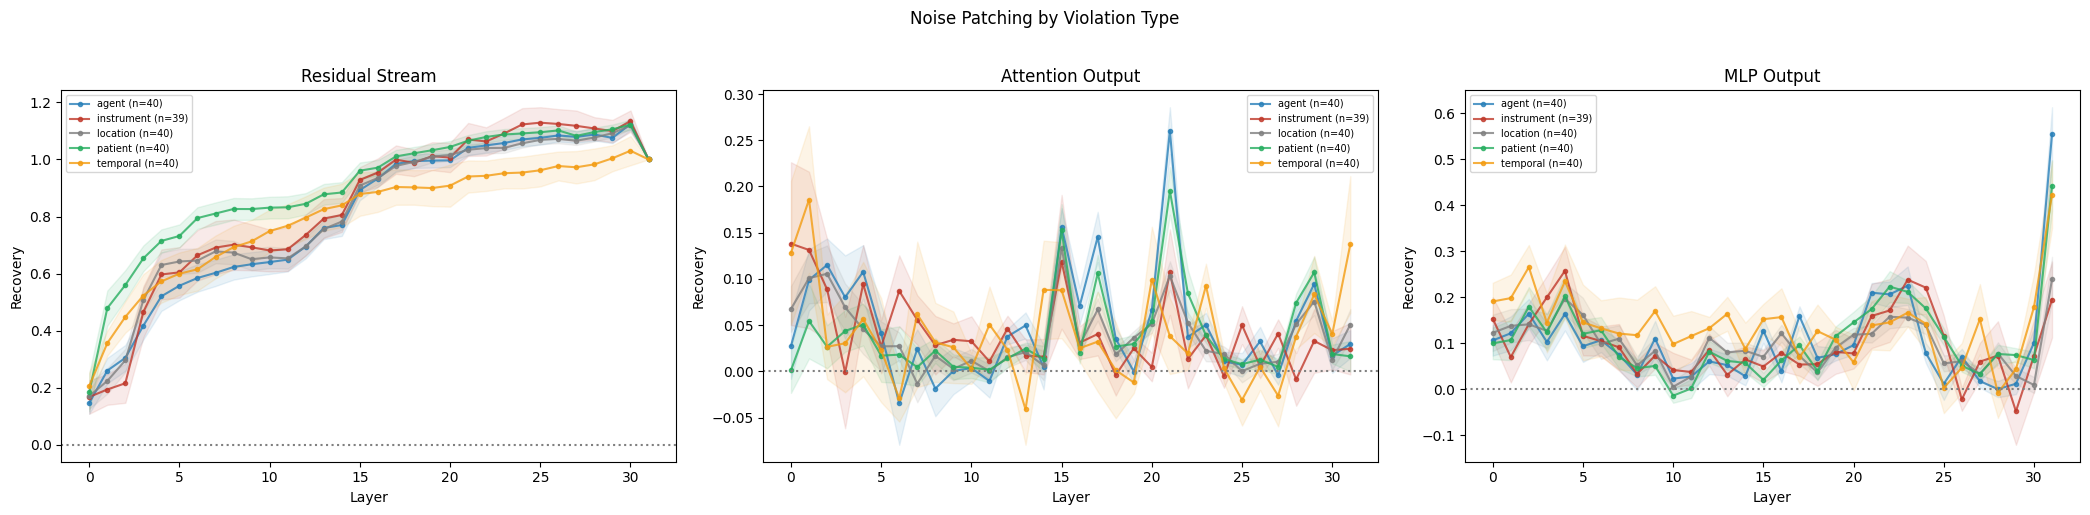

In [21]:
per_item = defaultdict(lambda: defaultdict(list))
for res in patch_results_all:
    vt = res['violation_type']
    for comp in COMPONENTS:
        vals = [np.clip(res.get(f'{comp}_L{l}', 0), -2, 3) for l in range(N_LAYERS)]
        per_item[vt][comp].append(vals)

fig, axes = plt.subplots(1, len(COMPONENTS), figsize=(7*len(COMPONENTS), 5))
if len(COMPONENTS) == 1: axes = [axes]
for ax, comp in zip(axes, COMPONENTS):
    for vt in sorted(per_item.keys()):
        arr = np.array(per_item[vt][comp])
        if len(arr) == 0: continue
        m = arr.mean(axis=0)
        se = arr.std(axis=0) / np.sqrt(len(arr))
        ax.plot(range(N_LAYERS), m, 'o-', label=f'{vt} (n={len(arr)})',
                color=vtype_colors.get(vt,'gray'), markersize=3, alpha=0.8)
        ax.fill_between(range(N_LAYERS), m-se, m+se, color=vtype_colors.get(vt,'gray'), alpha=0.1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Recovery')
    ax.set_title(comp_labels.get(comp, comp))
    ax.legend(fontsize=7)
    ax.axhline(0, color='gray', ls=':')
plt.suptitle('Noise Patching by Violation Type', y=1.02)
plt.tight_layout()
plt.savefig('study2_yogyata_noise_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Study 2c: Semantic Swap Activation Patching

In [22]:
def run_semantic_swap(model, good_str, bad_str, good_tok_id, bad_tok_id, attn_hook, mlp_hook):
    good_tokens = model.to_tokens(good_str)
    bad_tokens = model.to_tokens(bad_str)
    if good_tokens.shape[1] != bad_tokens.shape[1]:
        return None
    seq_len = good_tokens.shape[1]
    last_pos = seq_len - 1

    clean_logits, clean_cache = model.run_with_cache(good_tokens)
    clean_diff = (clean_logits[0, last_pos, good_tok_id] - clean_logits[0, last_pos, bad_tok_id]).item()

    corrupt_logits = model(bad_tokens)
    corrupt_diff = (corrupt_logits[0, last_pos, good_tok_id] - corrupt_logits[0, last_pos, bad_tok_id]).item()

    denom = clean_diff - corrupt_diff
    if abs(denom) < 0.1:
        return None

    results = {'clean_diff': clean_diff, 'corrupt_diff': corrupt_diff, 'denom': denom}

    for layer in range(model.cfg.n_layers):
        for comp, hook_suffix in [('attn', attn_hook), ('mlp', mlp_hook)]:
            if hook_suffix is None:
                continue
            hook_name = f'blocks.{layer}.{hook_suffix}'
            if hook_name not in clean_cache:
                continue
            clean_act = clean_cache[hook_name].clone()

            def patch_last(act, hook, ca=clean_act, lp=last_pos):
                act[:, lp, :] = ca[:, lp, :]
                return act

            patched_logits = model.run_with_hooks(
                bad_tokens, fwd_hooks=[(hook_name, patch_last)]
            )
            patched_diff = (patched_logits[0, last_pos, good_tok_id] - patched_logits[0, last_pos, bad_tok_id]).item()
            results[f'{comp}_L{layer}'] = (patched_diff - corrupt_diff) / denom

    return results

def run_swap_on_model(model, pairs, model_name, attn_hook, mlp_hook):
    swap_results = []
    with torch.no_grad():
        for pair in tqdm(pairs, desc=f'Semantic swap ({model_name})'):
            good_tok = model.to_tokens(' ' + pair['good_continuation'])[0, 1].item()
            bad_tok = model.to_tokens(' ' + pair['bad_continuation'])[0, 1].item()
            res = run_semantic_swap(
                model, pair['good_sentence'], pair['bad_sentence'],
                good_tok, bad_tok, attn_hook, mlp_hook
            )
            if res is not None:
                res['violation_type'] = pair['violation_type']
                swap_results.append(res)
    return swap_results

llama_swap = run_swap_on_model(llama, yogyata_pairs, 'LLaMA', ATTN_HOOK, MLP_HOOK)
print(f'LLaMA: {len(llama_swap)}/{len(yogyata_pairs)}')

# GPT-2 hook names
_, gc = gpt2.run_with_cache(gpt2.to_tokens('test'))
g2_hooks = [k.replace('blocks.0.','') for k in gc.keys() if 'blocks.0.' in k]
del gc
G2_ATTN = None
G2_MLP = None
for h in g2_hooks:
    if h in ('hook_attn_out', 'attn.hook_result', 'attn.hook_z'):
        G2_ATTN = h
    if h == 'hook_mlp_out':
        G2_MLP = h
if G2_ATTN is None:
    for h in g2_hooks:
        if 'attn' in h and ('out' in h or 'result' in h):
            G2_ATTN = h
            break
if G2_MLP is None:
    for h in g2_hooks:
        if 'mlp' in h and 'out' in h:
            G2_MLP = h
            break
print(f'GPT-2 hooks: ATTN={G2_ATTN}, MLP={G2_MLP}')

gpt2_swap = run_swap_on_model(gpt2, yogyata_pairs, 'GPT-2', G2_ATTN, G2_MLP)
print(f'GPT-2: {len(gpt2_swap)}/{len(yogyata_pairs)}')

Semantic swap (LLaMA):   0%|          | 0/200 [00:00<?, ?it/s]

LLaMA: 199/200
GPT-2 hooks: ATTN=hook_attn_out, MLP=hook_mlp_out


Semantic swap (GPT-2):   0%|          | 0/200 [00:00<?, ?it/s]

GPT-2: 190/200


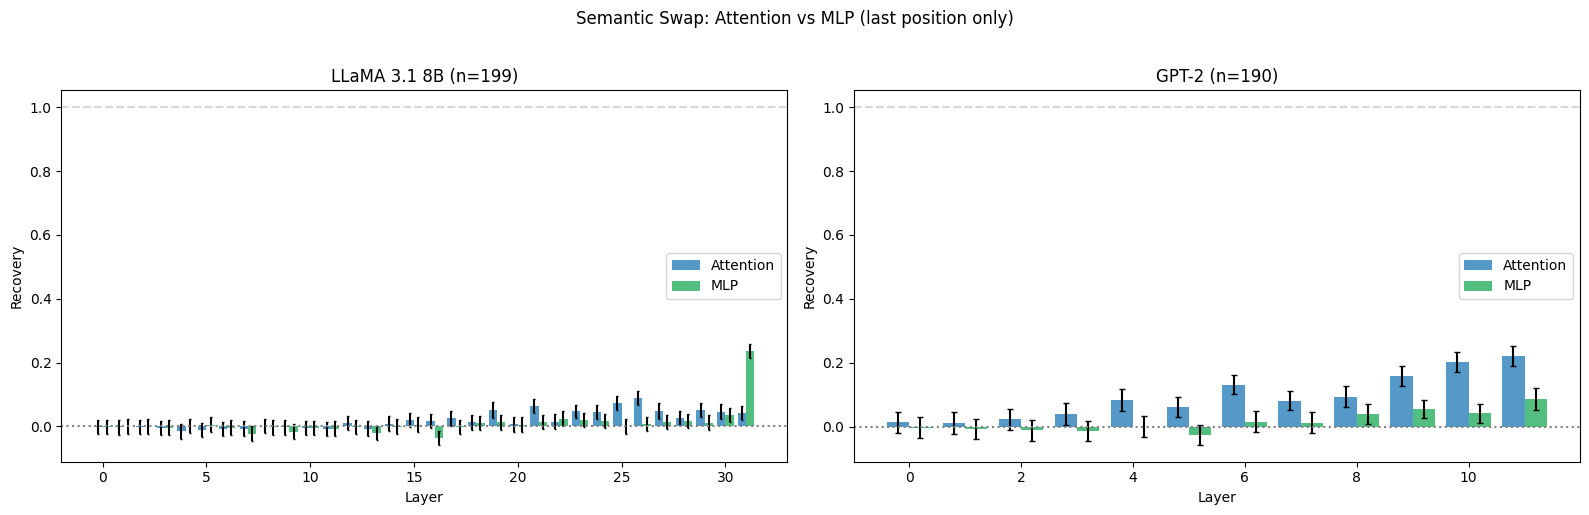

LLaMA attn: peak layer 26 (recovery=0.089)
LLaMA mlp: peak layer 31 (recovery=0.236)
GPT-2 attn: peak layer 11 (recovery=0.220)
GPT-2 mlp: peak layer 11 (recovery=0.086)


In [23]:
def compute_swap_curves(swap_results, n_layers):
    mc = np.mean([r['clean_diff'] for r in swap_results])
    mr = np.mean([r['corrupt_diff'] for r in swap_results])
    gd = mc - mr
    out = {}
    for comp in ['attn', 'mlp']:
        rec = np.zeros(n_layers)
        ci = np.zeros(n_layers)
        for layer in range(n_layers):
            key = f'{comp}_L{layer}'
            pds = [r['corrupt_diff'] + r.get(key, 0) * r['denom'] for r in swap_results if key in r]
            if pds:
                rec[layer] = (np.mean(pds) - mr) / gd
                boots = [np.mean(np.random.choice(pds, len(pds), replace=True)) for _ in range(500)]
                ci[layer] = np.std([(b - mr) / gd for b in boots])
        out[comp] = (rec, ci)
    return out

l_curves = compute_swap_curves(llama_swap, llama.cfg.n_layers)
g_curves = compute_swap_curves(gpt2_swap, gpt2.cfg.n_layers)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
w = 0.4
x_l = np.arange(llama.cfg.n_layers)
axes[0].bar(x_l - w/2, l_curves['attn'][0], w, yerr=l_curves['attn'][1],
            label='Attention', color='#2980b9', alpha=0.8, capsize=1)
axes[0].bar(x_l + w/2, l_curves['mlp'][0], w, yerr=l_curves['mlp'][1],
            label='MLP', color='#27ae60', alpha=0.8, capsize=1)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Recovery')
axes[0].set_title(f'LLaMA 3.1 8B (n={len(llama_swap)})')
axes[0].legend()
axes[0].axhline(0, color='gray', ls=':')
axes[0].axhline(1, color='gray', ls='--', alpha=0.3)

x_g = np.arange(gpt2.cfg.n_layers)
axes[1].bar(x_g - w/2, g_curves['attn'][0], w, yerr=g_curves['attn'][1],
            label='Attention', color='#2980b9', alpha=0.8, capsize=2)
axes[1].bar(x_g + w/2, g_curves['mlp'][0], w, yerr=g_curves['mlp'][1],
            label='MLP', color='#27ae60', alpha=0.8, capsize=2)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Recovery')
axes[1].set_title(f'GPT-2 (n={len(gpt2_swap)})')
axes[1].legend()
axes[1].axhline(0, color='gray', ls=':')
axes[1].axhline(1, color='gray', ls='--', alpha=0.3)

plt.suptitle('Semantic Swap: Attention vs MLP (last position only)', y=1.02)
plt.tight_layout()
plt.savefig('study2_yogyata_semantic_swap.png', dpi=150, bbox_inches='tight')
plt.show()

for name, curves in [('LLaMA', l_curves), ('GPT-2', g_curves)]:
    for comp in ['attn', 'mlp']:
        r = curves[comp][0]
        print(f'{name} {comp}: peak layer {np.argmax(r)} (recovery={r.max():.3f})')

---
# Study 3: Sannidhi -- Contiguity and the Effective Context Radius

## Data
313 passages (130--200 tokens) from `passages_merged_0_312.jsonl`. 50 long passages (~1000 tokens) from `sannidhi_1000_token_dataset.jsonl`.

## Methodology
### 3a. Attention decay: mean attention weight vs token distance, exponential fit.
### 3b. Long-range decay on LLaMA (RoPE), 1000-token passages.
### 3c. Functional distance: entity log-prob vs distance

In [24]:
passages_short = []
with open('passages_merged_0_312.jsonl', 'r') as f:
    for line in f:
        passages_short.append(json.loads(line))
passages_long = []
with open('sannidhi_1000_token_dataset.jsonl', 'r') as f:
    for line in f:
        passages_long.append(json.loads(line))
print(f'Short: {len(passages_short)}, Long: {len(passages_long)}')

Short: 313, Long: 50


In [25]:
def measure_decay_bert(texts, max_len=128, max_dist=60, n_texts=100):
    decay = defaultdict(lambda: defaultdict(list))
    for text in tqdm(texts[:n_texts], desc='BERT decay'):
        inputs = bert_tokenizer(text, return_tensors='pt', truncation=True, max_length=max_len).to(DEVICE)
        with torch.no_grad():
            out = bert_model(**inputs)
        sl = inputs['input_ids'].shape[1]
        for li, al in enumerate(out.attentions):
            aa = al[0].mean(dim=0)
            for i in range(1, sl-1):
                for j in range(1, sl-1):
                    if i != j:
                        d = abs(i-j)
                        if d <= max_dist:
                            decay[li][d].append(aa[i,j].item())
    return decay

def measure_decay_tl(model, texts, max_len=128, max_dist=60, n_texts=100, name='model'):
    decay = defaultdict(lambda: defaultdict(list))
    for text in tqdm(texts[:n_texts], desc=f'{name} decay'):
        tokens = model.to_tokens(text)[:, :max_len]
        sl = tokens.shape[1]
        if sl < 10: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens)
        for layer in range(model.cfg.n_layers):
            aa = cache[f'blocks.{layer}.attn.hook_pattern'][0].mean(dim=0)
            for i in range(1, sl-1):
                for j in range(1, i):
                    d = i - j
                    if d <= max_dist:
                        decay[layer][d].append(aa[i,j].item())
    return decay

text_list = [p['text'] for p in passages_short]
bert_decay = measure_decay_bert(text_list)
gpt2_decay = measure_decay_tl(gpt2, text_list, name='GPT-2')
llama_decay = measure_decay_tl(llama, text_list, n_texts=50, name='LLaMA')

BERT decay:   0%|          | 0/100 [00:00<?, ?it/s]

GPT-2 decay:   0%|          | 0/100 [00:00<?, ?it/s]

LLaMA decay:   0%|          | 0/50 [00:00<?, ?it/s]

BERT: A=0.0704, tau=2.65
GPT-2: A=0.1012, tau=3.50
LLaMA 3.1: A=0.0335, tau=5.69


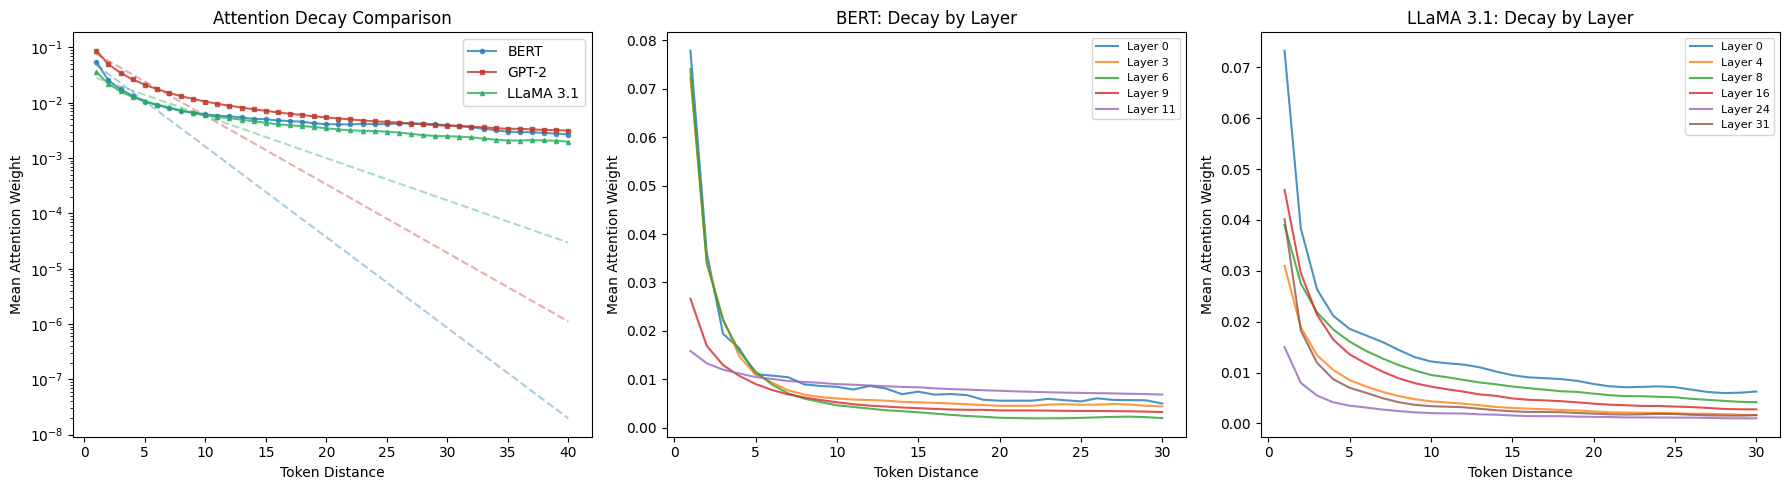

In [26]:
def compute_decay_curve(decay_data, layers_to_avg=None):
    if layers_to_avg is None:
        layers_to_avg = list(decay_data.keys())
    combined = defaultdict(list)
    for layer in layers_to_avg:
        for dist, weights in decay_data[layer].items():
            combined[dist].extend(weights)
    distances = sorted(combined.keys())
    means = [np.mean(combined[d]) for d in distances]
    sems = [np.std(combined[d]) / np.sqrt(len(combined[d])) for d in distances]
    return distances, means, sems

def exp_decay(x, A, tau):
    return A * np.exp(-np.array(x) / tau)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for mname, ddata, color, marker in [
    ('BERT', bert_decay, '#2980b9', 'o'),
    ('GPT-2', gpt2_decay, '#c0392b', 's'),
    ('LLaMA 3.1', llama_decay, '#27ae60', '^')
]:
    dists, means, _ = compute_decay_curve(ddata)
    dp, mp = dists[:40], means[:40]
    axes[0].plot(dp, mp, f'{marker}-', label=mname, color=color, markersize=3, alpha=0.8)
    try:
        popt, _ = curve_fit(exp_decay, dp, mp, p0=[mp[0], 10], maxfev=5000)
        axes[0].plot(dp, exp_decay(dp, *popt), '--', color=color, alpha=0.4)
        print(f'{mname}: A={popt[0]:.4f}, tau={popt[1]:.2f}')
    except: pass
axes[0].set_xlabel('Token Distance')
axes[0].set_ylabel('Mean Attention Weight')
axes[0].set_title('Attention Decay Comparison')
axes[0].legend()
axes[0].set_yscale('log')

for layer in [0,3,6,9,11]:
    d,m,_ = compute_decay_curve(bert_decay, [layer])
    axes[1].plot(d[:30], m[:30], '-', label=f'Layer {layer}', alpha=0.8)
axes[1].set_xlabel('Token Distance')
axes[1].set_ylabel('Mean Attention Weight')
axes[1].set_title('BERT: Decay by Layer')
axes[1].legend(fontsize=8)

for layer in [0,4,8,16,24,31]:
    if layer in llama_decay:
        d,m,_ = compute_decay_curve(llama_decay, [layer])
        axes[2].plot(d[:30], m[:30], '-', label=f'Layer {layer}', alpha=0.8)
axes[2].set_xlabel('Token Distance')
axes[2].set_ylabel('Mean Attention Weight')
axes[2].set_title('LLaMA 3.1: Decay by Layer')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig('study3_sannidhi_decay.png', dpi=150, bbox_inches='tight')
plt.show()

## Study 3b: Long-Range Decay (LLaMA, RoPE)

LLaMA long decay:   0%|          | 0/20 [00:00<?, ?it/s]

Long-range tau = 14.6


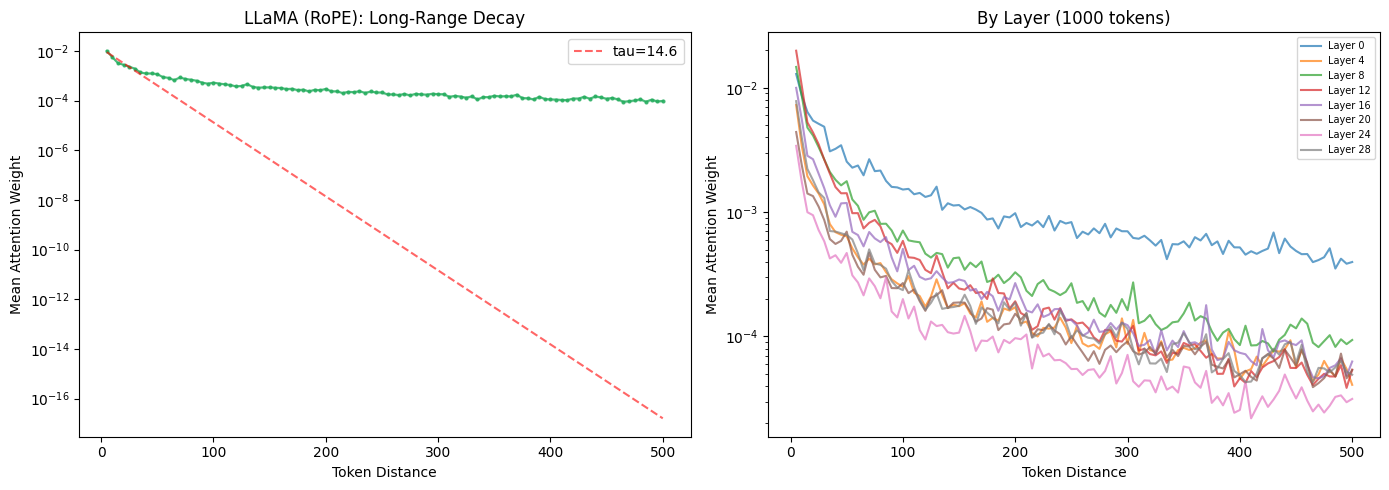

In [27]:
long_text_list = [p['text'] for p in passages_long]
def measure_decay_long(model, texts, max_len=1024, max_dist=500, n_texts=20):
    decay = defaultdict(lambda: defaultdict(list))
    sample_positions = list(range(50, max_len, 50))
    for text in tqdm(texts[:n_texts], desc='LLaMA long decay'):
        tokens = model.to_tokens(text)[:, :max_len]
        sl = tokens.shape[1]
        if sl < 100: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens)
        for layer in range(0, model.cfg.n_layers, 4):
            aa = cache[f'blocks.{layer}.attn.hook_pattern'][0].mean(dim=0)
            for i in sample_positions:
                if i >= sl: break
                for j in range(1, i):
                    d = i - j
                    if d <= max_dist and d % 5 == 0:
                        decay[layer][d].append(aa[i,j].item())
    return decay

llama_long_decay = measure_decay_long(llama, long_text_list)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dists, means, sems = compute_decay_curve(llama_long_decay)
axes[0].plot(dists, means, 'o-', color='#27ae60', markersize=2, alpha=0.8)
axes[0].fill_between(dists, [m-s for m,s in zip(means,sems)], [m+s for m,s in zip(means,sems)],
                     alpha=0.15, color='#27ae60')
try:
    popt, _ = curve_fit(exp_decay, dists, means, p0=[means[0], 50], maxfev=5000)
    axes[0].plot(dists, exp_decay(dists, *popt), 'r--', alpha=0.6, label=f'tau={popt[1]:.1f}')
    axes[0].legend()
    print(f'Long-range tau = {popt[1]:.1f}')
except: pass
axes[0].set_xlabel('Token Distance')
axes[0].set_ylabel('Mean Attention Weight')
axes[0].set_title('LLaMA (RoPE): Long-Range Decay')
axes[0].set_yscale('log')
for layer in sorted(llama_long_decay.keys()):
    d,m,_ = compute_decay_curve(llama_long_decay, [layer])
    axes[1].plot(d, m, '-', label=f'Layer {layer}', alpha=0.7)
axes[1].set_xlabel('Token Distance')
axes[1].set_ylabel('Mean Attention Weight')
axes[1].set_title('By Layer (1000 tokens)')
axes[1].legend(fontsize=7)
axes[1].set_yscale('log')
plt.tight_layout()
plt.savefig('study3b_sannidhi_long.png', dpi=150, bbox_inches='tight')
plt.show()

## Study 3c: Functional Distance Test

Fact-at-distance:   0%|          | 0/50 [00:00<?, ?it/s]

Spearman: r=-0.089, p=1.26e-01
Slope: mean=-0.000944, t=-4.152, p=1.31e-04, Cohen's d=-0.593


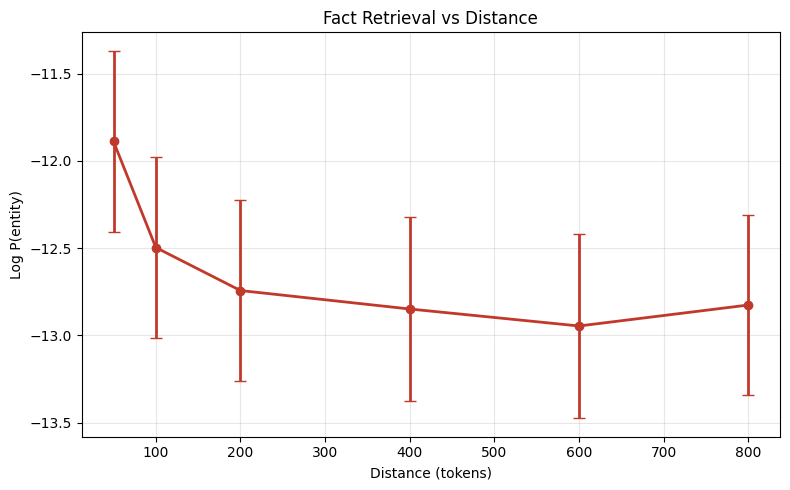

In [28]:
QUERY_TEMPLATE = '\nThe primary subject discussed in the passage above is'
DISTANCES = [50, 100, 200, 400, 600, 800]

def find_key_entity_token(model, text, n_candidates=30):
    tokens = model.to_tokens(text)
    str_tokens = model.to_str_tokens(tokens[0])
    skip = {'the','a','an','of','in','and','to','is','was','that','for','on','with','as',
            'it','its','this','by','from','at','<s>','</s>','<|endoftext|>','.',',',':',';'}
    for i in range(min(n_candidates, len(str_tokens))):
        tok_str = str_tokens[i].strip().lower()
        if len(tok_str) > 2 and tok_str not in skip and tok_str.isalpha():
            return tokens[0,i].item(), i, str_tokens[i]
    return tokens[0,3].item(), 3, str_tokens[3]

fact_results = []
query_tokens = llama.to_tokens(QUERY_TEMPLATE)
with torch.no_grad():
    for passage in tqdm(passages_long, desc='Fact-at-distance'):
        all_tokens = llama.to_tokens(passage['text'])[0]
        if len(all_tokens) < 800: continue
        entity_id, _, entity_str = find_key_entity_token(llama, passage['text'])
        for d in DISTANCES:
            if d > len(all_tokens): continue
            full_input = torch.cat([all_tokens[:d].unsqueeze(0), query_tokens], dim=1)
            logits = llama(full_input)[0, -1]
            lp = F.log_softmax(logits.float(), dim=-1)[entity_id].item()
            fact_results.append({'passage_id': passage['passage_id'], 'distance': d,
                                 'log_prob': lp, 'entity': entity_str.strip()})

df_dist = pd.DataFrame(fact_results)
fig, ax = plt.subplots(figsize=(8, 5))
dm = df_dist.groupby('distance')['log_prob'].agg(['mean','sem']).reset_index()
ax.errorbar(dm['distance'], dm['mean'], yerr=dm['sem'], fmt='o-', color='#c0392b', capsize=4, linewidth=2)
ax.set_xlabel('Distance (tokens)')
ax.set_ylabel('Log P(entity)')
ax.set_title('Fact Retrieval vs Distance')
ax.grid(alpha=0.3)
r, p = stats.spearmanr(df_dist['distance'], df_dist['log_prob'])
print(f'Spearman: r={r:.3f}, p={p:.2e}')
slopes = []
for pid, grp in df_dist.groupby('passage_id'):
    if len(grp) >= 3:
        sl, _, _, _, _ = stats.linregress(grp['distance'], grp['log_prob'])
        slopes.append(sl)
slopes = np.array(slopes)
t_sl, p_sl = stats.ttest_1samp(slopes, 0)
print(f"Slope: mean={slopes.mean():.6f}, t={t_sl:.3f}, p={p_sl:.2e}, Cohen's d={slopes.mean()/slopes.std():.3f}")
plt.tight_layout()
plt.savefig('study3c_fact_distance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Study 4: Polysemy Crossover -- Sense vs Lexical Identity

## Data
`polysemy_templates_final_balanced.csv`: 50 sentences per word, 2 senses, 25 per sense.

## Methodology
Silhouette score for sense clustering (within-word) and lexical identity clustering (across words) at each BERT layer. Crossover layer = where sense separability exceeds identity. Bootstrap (500 resamples over words) with corrected identity labels for duplicate words.

In [6]:
df_poly = pd.read_csv('polysemy_templates_final_balanced.csv')
print(f'Polysemy: {len(df_poly)} rows, words: {df_poly["word"].unique().tolist()}')

Polysemy: 1950 rows, words: ['ball', 'bank', 'bark', 'bass', 'bat', 'bill', 'bolt', 'bow', 'calf', 'charge', 'check', 'chest', 'club', 'court', 'crane', 'current', 'draft', 'fair', 'fan', 'figure', 'file', 'foil', 'glasses', 'ground', 'jam', 'key', 'match', 'mole', 'nail', 'palm', 'plane', 'port', 'ring', 'row', 'scale', 'seal', 'spring', 'trunk', 'watch']


In [12]:
poly_reps_bert = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
with torch.no_grad():
    for _, row in tqdm(df_poly.iterrows(), total=len(df_poly), desc='BERT reps'):
        word, sense, sent = row['word'], row['sense_id'], row['sentence']
        inputs = bert_tokenizer(sent, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)
        token_strs = bert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        target_pos = [i for i, t in enumerate(token_strs)
                      if word.lower() in t.lower() and t not in ['[CLS]','[SEP]']]
        if not target_pos: continue
        out = bert_model(**inputs)
        pos = target_pos[0]
        for li, hidden in enumerate(out.hidden_states):
            poly_reps_bert[word][sense][li].append(hidden[0, pos].cpu().numpy())
n_layers_bert = 13
words_bert = sorted(poly_reps_bert.keys())
print(f'BERT: {len(words_bert)} words')

BERT reps:   0%|          | 0/1950 [00:00<?, ?it/s]

BERT: 39 words


In [13]:
def compute_crossover(poly_reps, words, n_layers, n_boot=500):
    sense_sil, identity_sil = [], []
    for layer in range(n_layers):
        ws = []
        for w in words:
            r0 = poly_reps[w][0].get(layer, [])
            r1 = poly_reps[w][1].get(layer, [])
            if len(r0) < 5 or len(r1) < 5: continue
            X = np.vstack(r0 + r1)
            y = np.array([0]*len(r0) + [1]*len(r1))
            if len(X) >= 6:
                ws.append(silhouette_score(X, y))
        sense_sil.append(np.mean(ws) if ws else 0)

        ar, al = [], []
        for wi, w in enumerate(words):
            for s in [0, 1]:
                reps = poly_reps[w][s].get(layer, [])
                ar.extend(reps)
                al.extend([wi]*len(reps))
        if len(ar) >= 10 and len(set(al)) >= 2:
            identity_sil.append(silhouette_score(np.vstack(ar), np.array(al)))
        else:
            identity_sil.append(0)

    crossover = None
    for i in range(1, n_layers):
        if sense_sil[i] > identity_sil[i] and sense_sil[i-1] <= identity_sil[i-1]:
            crossover = i
            break

    boot_crossovers = []
    for _ in range(n_boot):
        bw = list(np.random.choice(words, len(words), replace=True))

        # Map duplicate words to unique indices for identity metric
        unique_words = list(dict.fromkeys(bw))
        word_to_uid = {w: i for i, w in enumerate(unique_words)}

        bs, bi_list = [], []
        for layer in range(n_layers):
            ws_s = []
            for w in bw:
                r0 = poly_reps[w][0].get(layer, [])
                r1 = poly_reps[w][1].get(layer, [])
                if len(r0) < 5 or len(r1) < 5: continue
                X = np.vstack(r0 + r1)
                y = np.array([0]*len(r0) + [1]*len(r1))
                if len(X) >= 6:
                    ws_s.append(silhouette_score(X, y))
            bs.append(np.mean(ws_s) if ws_s else 0)

            ar, al = [], []
            for w in bw:
                uid = word_to_uid[w]
                for s in [0, 1]:
                    reps = poly_reps[w][s].get(layer, [])
                    ar.extend(reps)
                    al.extend([uid]*len(reps))
            if len(ar) >= 10 and len(set(al)) >= 2:
                bi_list.append(silhouette_score(np.vstack(ar), np.array(al)))
            else:
                bi_list.append(0)

        bc = None
        for i in range(1, n_layers):
            if bs[i] > bi_list[i] and bs[i-1] <= bi_list[i-1]:
                bc = i
                break
        if bc is not None:
            boot_crossovers.append(bc)

    return sense_sil, identity_sil, crossover, boot_crossovers

print('BERT crossover...')
bert_ss, bert_is, bert_xo, bert_boots = compute_crossover(poly_reps_bert, words_bert, n_layers_bert)
print(f'BERT crossover: {bert_xo}')
if bert_boots:
    print(f'Bootstrap: median={np.median(bert_boots):.0f}, '
          f'95% CI=[{np.percentile(bert_boots,2.5):.0f}, {np.percentile(bert_boots,97.5):.0f}], '
          f'{len(bert_boots)}/500 had crossover')

BERT crossover...
BERT crossover: 6
Bootstrap: median=7, 95% CI=[5, 8], 500/500 had crossover


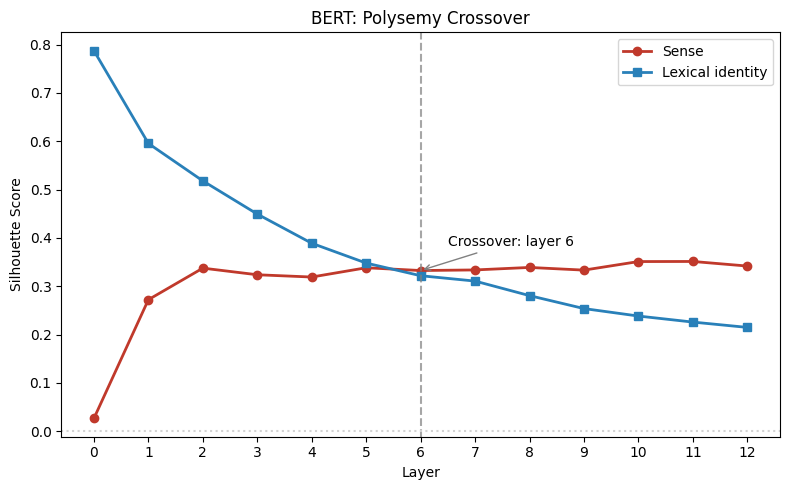

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(n_layers_bert), bert_ss, 'o-', label='Sense', color='#c0392b', linewidth=2)
plt.plot(range(n_layers_bert), bert_is, 's-', label='Lexical identity', color='#2980b9', linewidth=2)

if bert_xo is not None:
    plt.axvline(bert_xo, color='gray', ls='--', alpha=0.7)
    plt.annotate(f'Crossover: layer {bert_xo}', xy=(bert_xo, bert_ss[bert_xo]),
                xytext=(bert_xo+0.5, bert_ss[bert_xo]+0.05),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

plt.xlabel('Layer')
plt.ylabel('Silhouette Score')
plt.title('BERT: Polysemy Crossover')
plt.legend()
plt.xticks(range(n_layers_bert))
plt.axhline(0, color='lightgray', ls=':')
plt.tight_layout()
plt.savefig('study4_polysemy_crossover.png', dpi=300, bbox_inches='tight')
plt.show()

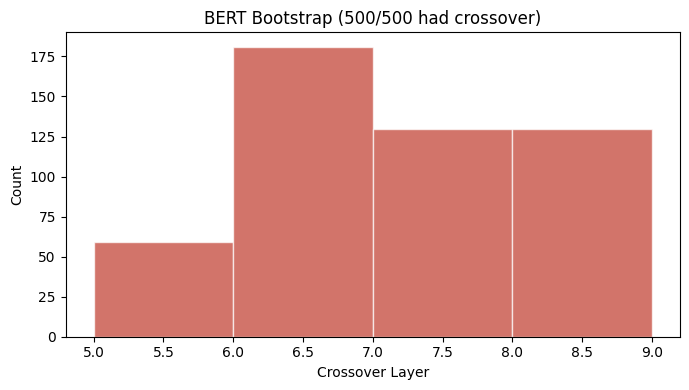

In [15]:
plt.figure(figsize=(7, 4))
if bert_boots:
    plt.hist(bert_boots, bins=range(min(bert_boots), max(bert_boots)+2),
            color='#c0392b', alpha=0.7, edgecolor='white')
    plt.xlabel('Crossover Layer')
    plt.ylabel('Count')
    plt.title(f'BERT Bootstrap ({len(bert_boots)}/500 had crossover)')

plt.tight_layout()
plt.savefig('study4_bootstrap_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Synthesis

In [37]:
import zipfile
figures = [
    'study1_akanksha_heatmaps.png', 'study1_distance_bins.png', 'study1_paired_knockout.png',
    'study2_yogyata_baseline.png', 'study2_yogyata_noise_patching.png',
    'study2_yogyata_noise_by_type.png', 'study2_yogyata_semantic_swap.png',
    'study3_sannidhi_decay.png', 'study3b_sannidhi_long.png',
    'study3c_fact_distance.png', 'study3c_patching.png',
    'study4_polysemy_crossover.png', 'study4_bootstrap_crossover.png',
    'combined_figure.png'
]
with zipfile.ZipFile('all_figures.zip', 'w') as zipf:
    for f in figures:
        if os.path.exists(f): zipf.write(f)
from google.colab import files
files.download('all_figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Appendix: Environment

Python 3.10+, PyTorch 2.0+, transformers >= 4.30, transformer-lens >= 1.0, CUDA 11.8+. Seeds fixed at 42.